# **Import** **Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline

from sklearn.metrics import confusion_matrix

# **Load** **Pre**-**trained** **BERT** **Model**

In [3]:
classifier = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# **Test the Model**

In [4]:
text = "I love Artificial Intelligence."

result = classifier(text)

print(result)

[{'label': '5 stars', 'score': 0.7978376150131226}]


# **Create Sample Dataset**

In [5]:
texts = [

"I love this movie.",

"The food was terrible.",

"This phone is amazing.",

"I hate waiting in traffic.",

"The teacher explained everything clearly.",

"The laptop is slow.",

"I really enjoyed the workshop.",

"This product is useless."

]


# **Predict Sentiment**

In [6]:
results = []

for sentence in texts:

    prediction = classifier(sentence)[0]

    results.append({
        "Text": sentence,
        "Sentiment": prediction["label"],
        "Confidence": prediction["score"]
    })

df = pd.DataFrame(results)

df

,Text,Sentiment,Confidence
0,I love this movie.,5 stars,0.893850
1,The food was terrible.,1 star,0.655274
2,This phone is amazing.,5 stars,0.878466
3,I hate waiting in traffic.,1 star,0.397021
4,The teacher explained everything clearly.,5 stars,0.442838
5,The laptop is slow.,2 stars,0.461036
6,I really enjoyed the workshop.,4 stars,0.510396
7,This product is useless.,1 star,0.877960


# **Save Results**

In [8]:
df.to_csv("results.csv", index=False)

# **Visualization**

**Sentiment Distribution**

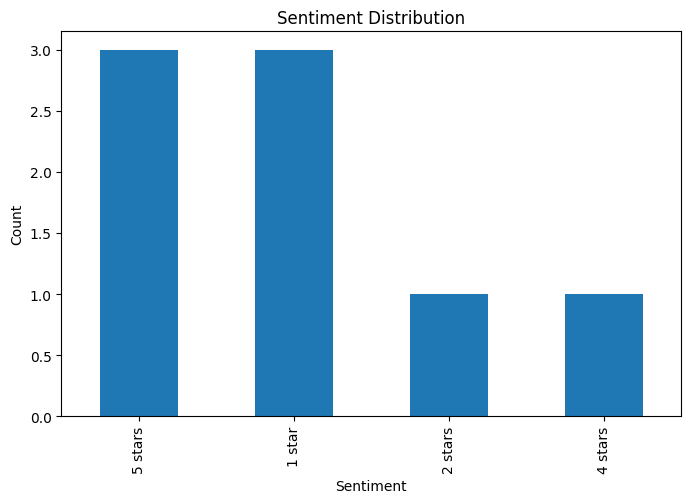

In [9]:
plt.figure(figsize=(8,5))

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

**Confidence Scores**

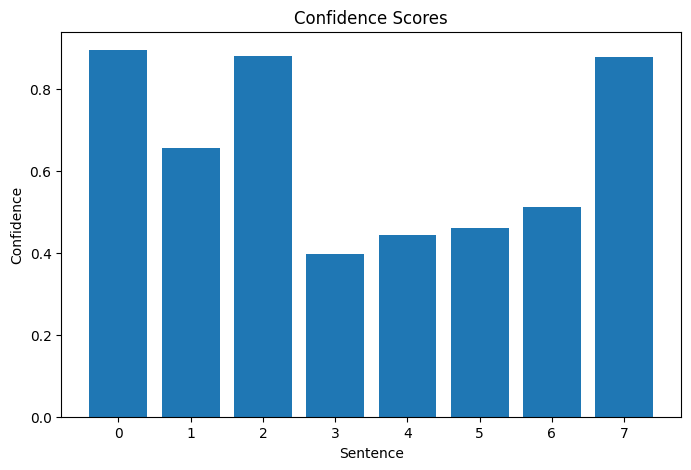

In [10]:
plt.figure(figsize=(8,5))

plt.bar(df.index, df["Confidence"])

plt.title("Confidence Scores")

plt.xlabel("Sentence")

plt.ylabel("Confidence")

plt.show()